✓ Figure 1.1 saved as PNG and PDF


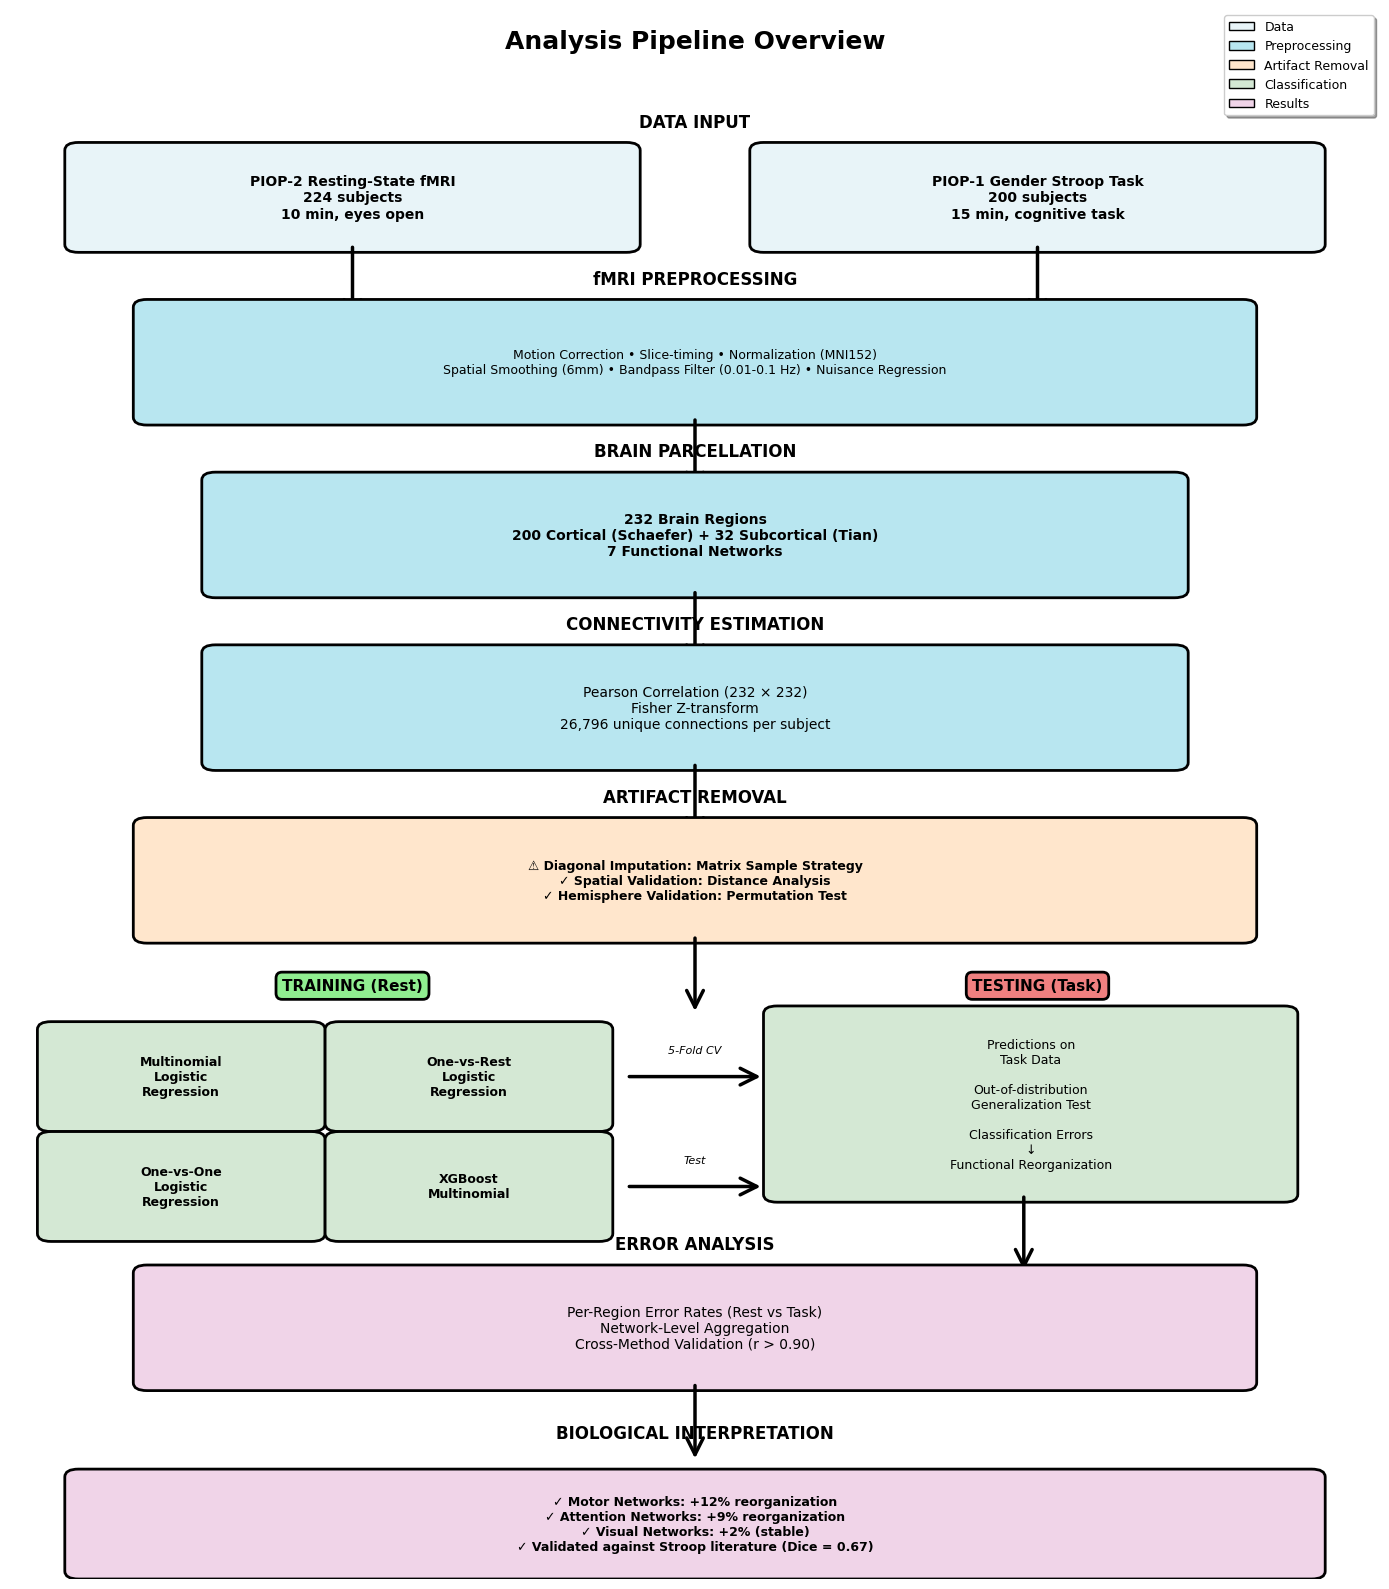

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(14, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Define colors
color_data = '#E8F4F8'
color_preproc = '#B8E6F0'
color_artifact = '#FFE6CC'
color_method = '#D4E8D4'
color_result = '#F0D4E8'

# Helper function to create boxes
def create_box(ax, x, y, width, height, text, color, fontsize=11, fontweight='normal'):
    box = FancyBboxPatch((x, y), width, height, 
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', 
                         facecolor=color, 
                         linewidth=2)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, 
           ha='center', va='center', 
           fontsize=fontsize, fontweight=fontweight, 
           wrap=True)

# Helper function to create arrows
def create_arrow(ax, x1, y1, x2, y2, label='', style='->'):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                          arrowstyle=style, 
                          color='black', 
                          linewidth=2.5,
                          mutation_scale=30)
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2)/2, (y1 + y2)/2
        ax.text(mid_x + 0.3, mid_y, label, 
               fontsize=9, style='italic',
               bbox=dict(boxstyle='round,pad=0.3', 
                        facecolor='white', 
                        edgecolor='gray'))

# Title
ax.text(5, 19.5, 'Analysis Pipeline Overview', 
       fontsize=18, fontweight='bold', ha='center')

# ============= DATA INPUT =============
ax.text(5, 18.5, 'DATA INPUT', fontsize=12, fontweight='bold', ha='center')

# PIOP-2 Rest
create_box(ax, 0.5, 17, 4, 1.2, 
          'PIOP-2 Resting-State fMRI\n224 subjects\n10 min, eyes open', 
          color_data, fontsize=10, fontweight='bold')

# PIOP-1 Task
create_box(ax, 5.5, 17, 4, 1.2, 
          'PIOP-1 Gender Stroop Task\n200 subjects\n15 min, cognitive task', 
          color_data, fontsize=10, fontweight='bold')

# Arrow down from both
create_arrow(ax, 2.5, 17, 2.5, 16)
create_arrow(ax, 7.5, 17, 7.5, 16)

# ============= PREPROCESSING =============
ax.text(5, 16.5, 'fMRI PREPROCESSING', fontsize=12, fontweight='bold', ha='center')

create_box(ax, 1, 14.8, 8, 1.4, 
          'Motion Correction • Slice-timing • Normalization (MNI152)\n' +
          'Spatial Smoothing (6mm) • Bandpass Filter (0.01-0.1 Hz) • Nuisance Regression', 
          color_preproc, fontsize=9)

create_arrow(ax, 5, 14.8, 5, 13.8)

# ============= PARCELLATION =============
ax.text(5, 14.3, 'BRAIN PARCELLATION', fontsize=12, fontweight='bold', ha='center')

create_box(ax, 1.5, 12.6, 7, 1.4, 
          '232 Brain Regions\n200 Cortical (Schaefer) + 32 Subcortical (Tian)\n' +
          '7 Functional Networks', 
          color_preproc, fontsize=10, fontweight='bold')

create_arrow(ax, 5, 12.6, 5, 11.6)

# ============= CONNECTIVITY =============
ax.text(5, 12.1, 'CONNECTIVITY ESTIMATION', fontsize=12, fontweight='bold', ha='center')

create_box(ax, 1.5, 10.4, 7, 1.4, 
          'Pearson Correlation (232 × 232)\n' +
          'Fisher Z-transform\n' +
          '26,796 unique connections per subject', 
          color_preproc, fontsize=10)

create_arrow(ax, 5, 10.4, 5, 9.4)

# ============= ARTIFACT REMOVAL =============
ax.text(5, 9.9, 'ARTIFACT REMOVAL', fontsize=12, fontweight='bold', ha='center')

create_box(ax, 1, 8.2, 8, 1.4, 
          '⚠ Diagonal Imputation: Matrix Sample Strategy\n' +
          '✓ Spatial Validation: Distance Analysis\n' +
          '✓ Hemisphere Validation: Permutation Test', 
          color_artifact, fontsize=9, fontweight='bold')

create_arrow(ax, 5, 8.2, 5, 7.2)

# ============= TRAINING (REST) =============
ax.text(2.5, 7.5, 'TRAINING (Rest)', fontsize=11, fontweight='bold', ha='center', 
       bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', edgecolor='black', linewidth=2))

# Four classifiers
create_box(ax, 0.3, 5.8, 1.9, 1.2, 
          'Multinomial\nLogistic\nRegression', 
          color_method, fontsize=9, fontweight='bold')

create_box(ax, 2.4, 5.8, 1.9, 1.2, 
          'One-vs-Rest\nLogistic\nRegression', 
          color_method, fontsize=9, fontweight='bold')

create_box(ax, 0.3, 4.4, 1.9, 1.2, 
          'One-vs-One\nLogistic\nRegression', 
          color_method, fontsize=9, fontweight='bold')

create_box(ax, 2.4, 4.4, 1.9, 1.2, 
          'XGBoost\nMultinomial', 
          color_method, fontsize=9, fontweight='bold')

# Arrows from training to testing
create_arrow(ax, 4.5, 6.4, 5.5, 6.4, style='->')
create_arrow(ax, 4.5, 5, 5.5, 5, style='->')

ax.text(5, 6.7, '5-Fold CV', fontsize=8, ha='center', style='italic')
ax.text(5, 5.3, 'Test', fontsize=8, ha='center', style='italic')

# ============= TESTING (TASK) =============
ax.text(7.5, 7.5, 'TESTING (Task)', fontsize=11, fontweight='bold', ha='center',
       bbox=dict(boxstyle='round,pad=0.4', facecolor='lightcoral', edgecolor='black', linewidth=2))

# Predictions
create_box(ax, 5.6, 4.9, 3.7, 2.3, 
          'Predictions on\nTask Data\n\n' +
          'Out-of-distribution\nGeneralization Test\n\n' +
          'Classification Errors\n↓\nFunctional Reorganization', 
          color_method, fontsize=9)

# Arrow down
create_arrow(ax, 7.4, 4.9, 7.4, 3.9)

# ============= ERROR ANALYSIS =============
ax.text(5, 4.2, 'ERROR ANALYSIS', fontsize=12, fontweight='bold', ha='center')

create_box(ax, 1, 2.5, 8, 1.4, 
          'Per-Region Error Rates (Rest vs Task)\n' +
          'Network-Level Aggregation\n' +
          'Cross-Method Validation (r > 0.90)', 
          color_result, fontsize=10)

create_arrow(ax, 5, 2.5, 5, 1.5)

# ============= BIOLOGICAL INTERPRETATION =============
ax.text(5, 1.8, 'BIOLOGICAL INTERPRETATION', fontsize=12, fontweight='bold', ha='center')

create_box(ax, 0.5, 0.1, 9, 1.2, 
          '✓ Motor Networks: +12% reorganization\n' +
          '✓ Attention Networks: +9% reorganization\n' +
          '✓ Visual Networks: +2% (stable)\n' +
          '✓ Validated against Stroop literature (Dice = 0.67)', 
          color_result, fontsize=9, fontweight='bold')

# Add legend for colors
legend_elements = [
    mpatches.Patch(facecolor=color_data, edgecolor='black', label='Data'),
    mpatches.Patch(facecolor=color_preproc, edgecolor='black', label='Preprocessing'),
    mpatches.Patch(facecolor=color_artifact, edgecolor='black', label='Artifact Removal'),
    mpatches.Patch(facecolor=color_method, edgecolor='black', label='Classification'),
    mpatches.Patch(facecolor=color_result, edgecolor='black', label='Results')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, 
         frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()